In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../Data/Train.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
cluster_df = df[['Cost_of_the_Product','Discount_offered']]
cluster_df.head()

,Cost_of_the_Product,Discount_offered
0,306,45
1,114,35
2,215,44
3,126,54
4,113,43


In [5]:
cluster_df = cluster_df.dropna()
print("Shape after removing null values:", cluster_df.shape)

Shape after removing null values: (1000, 2)


In [6]:
cluster_df['Cost_log'] = np.log1p(cluster_df['Cost_of_the_Product'])
cluster_df['Discount_log'] = np.log1p(cluster_df['Discount_offered'])
cluster_df[['Cost_log','Discount_log']].head()

,Cost_log,Discount_log
0,5.726848,3.828641
1,4.744932,3.583519
2,5.375278,3.806662
3,4.844187,4.007333
4,4.736198,3.784190


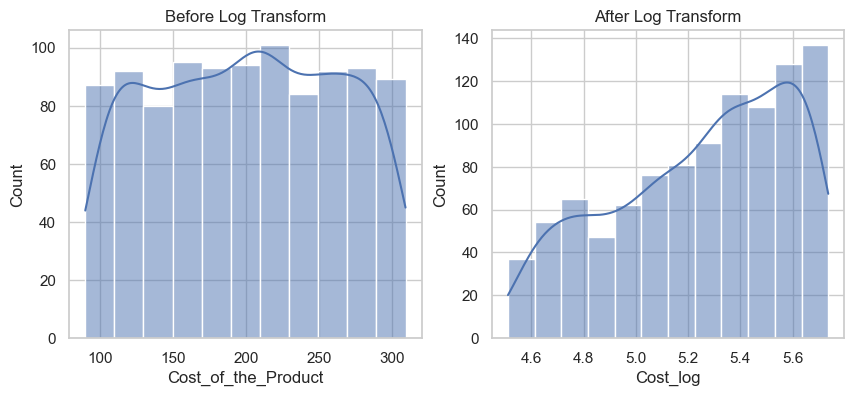

In [7]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(cluster_df['Cost_of_the_Product'], kde=True)
plt.title("Before Log Transform")
plt.subplot(1,2,2)
sns.histplot(cluster_df['Cost_log'], kde=True)
plt.title("After Log Transform")
plt.show()

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[['Cost_log','Discount_log']])

In [10]:
kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
)
clusters = kmeans.fit_predict(X)
cluster_df['Cluster'] = clusters
cluster_df.head()

,Cost_of_the_Product,Discount_offered,Cost_log,Discount_log,Cluster
0,306,45,5.726848,3.828641,0
1,114,35,4.744932,3.583519,1
2,215,44,5.375278,3.806662,0
3,126,54,4.844187,4.007333,1
4,113,43,4.736198,3.784190,1


In [11]:
for i in range(3):
    print("\nCluster", i)
    print(cluster_df[cluster_df['Cluster']==i].describe())


Cluster 0
       Cost_of_the_Product  Discount_offered    Cost_log  Discount_log  \
count           480.000000        480.000000  480.000000    480.000000   
mean            242.854167         40.197917    5.483563      3.649630   
std              38.901776         14.219000    0.162545      0.387267   
min             174.000000         13.000000    5.164786      2.639057   
25%             210.000000         28.000000    5.351858      3.367296   
50%             243.000000         41.000000    5.497168      3.737670   
75%             277.000000         53.000000    5.627621      3.988984   
max             309.000000         64.000000    5.736572      4.174387   

       Cluster  
count    480.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  

Cluster 1
       Cost_of_the_Product  Discount_offered    Cost_log  Discount_log  \
count           310.000000        310.000000  310.000000    310.000000   
mean      

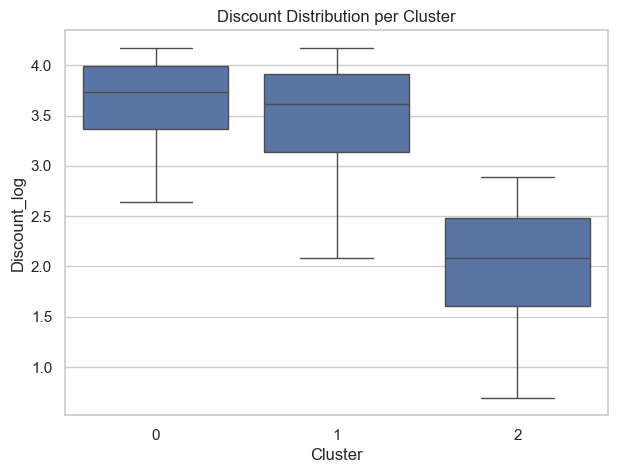

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Cluster',
    y='Discount_log',
    data=cluster_df
)

plt.title("Discount Distribution per Cluster")
plt.show()

In [14]:
print("Cluster Centers:\n")
print(kmeans.cluster_centers_)

Cluster Centers:

[[ 0.68835467  0.49281064]
 [-1.14524383  0.31255354]
 [ 0.11721594 -1.58781288]]
